In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from voluntary_fixation.envs import TR, RUN_IDS, SUBJECT_IDS, SAVE_ROOT, NUM_ROIS, BRIGHTNESS_DIR, RUN_VOLUMES, MOVIE_FPS
import os
from scipy.stats import ttest_1samp

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [2]:

def plot(scores_rois, ax, delay_list, baseline, ylim, title='', yscale='linear', ylabel='Mean correlation score'):
    for roi in range(NUM_ROIS):
        ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=f'roi {roi}')
    ax.set_xlabel('lag Δτ [sec]')
    ax.set_ylabel(ylabel)
    # ax.legend()
    ax.set_xticks(np.arange(len(delay_list)))
    ax.set_xticklabels([2*d for d in delay_list])
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.hlines(baseline, 0, len(delay_list)-1, colors='k', linestyles='dashed')
    ax.set_yscale(yscale)

In [3]:
delays = [-3,-2, -1, 0, 1, 2, 3, 4,5]
frame_offset = 0
mask_offset = 0
modality = 'masked_image'
sampling_mode = 'segment'
iou_q = 0.5
eyemovement_q = 0.9
saliency_q = 0.9
n_components = 250
saliency_label = 'avg_shift_norm'
gaze_shift_label = ['FIXA', 'PURS']

rm_empty_eyetrack = True
rs_str = '-rm_empty_eyetrack' if rm_empty_eyetrack else ''
label_mode = 'public'

csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2location', f'eval_specific{label_mode}')


../../../../results/voluntary_fixation/bold2location/eval_specificpublic raw_corr-FIXA_PURS_q0.9-sal_q0.9.csv
delay: -3,  wo_sal: [], w_sal: []
wo_sal p_value:  []
w_sal p_value:  []
wo_sal corr:  []
w_sal corr:  []
delay: -2,  wo_sal: [], w_sal: []
wo_sal p_value:  []
w_sal p_value:  []
wo_sal corr:  []
w_sal corr:  []
delay: -1,  wo_sal: [18], w_sal: []
wo_sal p_value:  [5.18436074e-05]
w_sal p_value:  []
wo_sal corr:  [0.12271816]
w_sal corr:  []
delay: 0,  wo_sal: [0, 1, 12, 13, 18, 22, 23, 35], w_sal: [1, 11, 12, 13, 23]
wo_sal p_value:  [4.85696461e-06 2.44960902e-07 5.91242403e-05 5.86177750e-05
 6.36887612e-06 1.35844093e-05 2.57418909e-07 1.06985229e-05]
w_sal p_value:  [1.93399940e-05 3.33187159e-05 5.18012242e-05 2.72590125e-05
 4.34429456e-07]
wo_sal corr:  [0.14596629 0.15702865 0.1279277  0.18604063 0.19258662 0.11646076
 0.15861474 0.16981122]
w_sal corr:  [0.16459823 0.13978663 0.15119397 0.1801146  0.14286118]
delay: 1,  wo_sal: [0, 1, 2, 3, 6, 12, 13, 17, 18, 22, 23, 

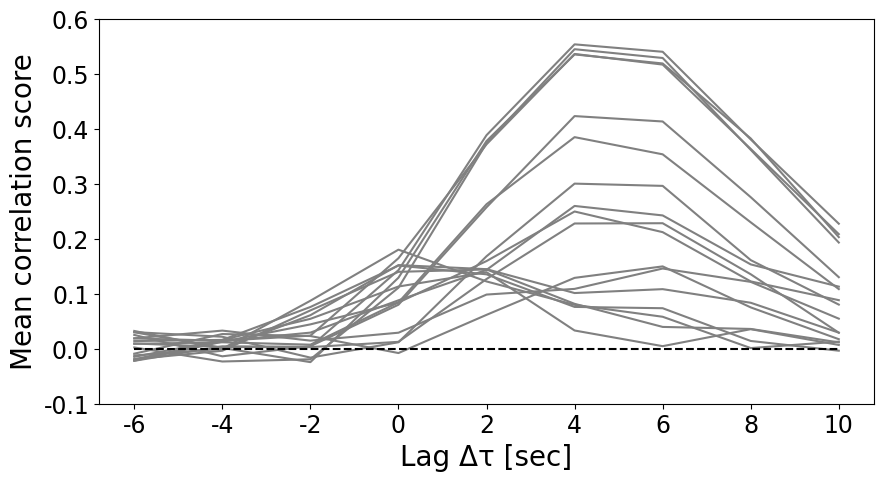

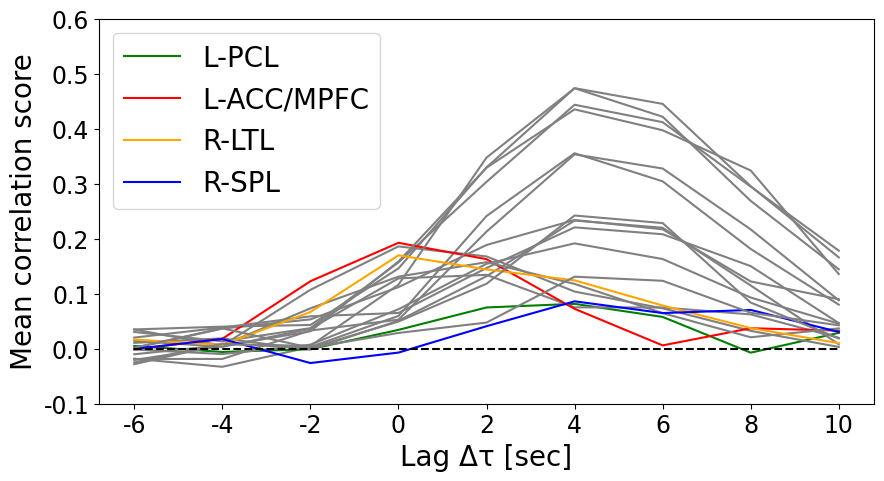

In [ ]:
csv_dir_format = os.path.join(csv_dir, 'delay{delay}')
raw_corr_filename = f'raw_corr-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv'
stats_test_filename = f'statistics_test-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv'
print(csv_dir, raw_corr_filename)
artifact_indices =[19, 41]# [12,13, 18, 19, 31, 33, 34, 35, 41]#[11, 12,13, 18, 19, 31, 33, 34, 35, 41]# + [0,1,2,3,4,22,23,24,25,26] #+ [9,10,21,32,42,43,5,8,20,27,30]
artifact_indices = list(set(artifact_indices))

def plot_sig(sig_rois_across_time, scores_rois, ax, delay_list, baseline, ylim, title='', yscale='linear', ylabel='Mean correlation score',
             color=None, legend=True):
    # num_sig_rois =
    for roi in sig_rois_across_time:
        if color is not None:
            c, label = color.get(roi, ('gray', None))
            if label is not None:
                ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=label, color=c)
            else:
                ax.plot(np.arange(len(delay_list)), scores_rois[roi], color=c)
        else:
            ax.plot(np.arange(len(delay_list)), scores_rois[roi], label=f'roi {roi}')
    ax.set_xlabel('Lag Δτ [sec]')
    ax.set_ylabel(ylabel)
    # ax.legend()
    ax.set_xticks(np.arange(len(delay_list)))
    ax.set_xticklabels([d*TR for d in delay_list])
    ax.set_ylim(ylim)
    if title is not None:
        ax.set_title(title)
    ax.hlines(baseline, 0, len(delay_list)-1, colors='k', linestyles='dashed')
    ax.set_yscale(yscale)
    if legend and color is not None:
        ax.legend()


target_delays = [-3,-2,-1,0,1,2,3,4,5]
num_condition = 2
wo_sal_sets = []
w_sal_sets = []
p_criterion = 0.05/(NUM_ROIS-len(artifact_indices))/len(target_delays)/num_condition # delta_t = 1,2,3,4,5
p_value_series_w_sal = np.ones((NUM_ROIS, len(target_delays)))
raw_corr_series_w_sal = np.ones((NUM_ROIS, len(target_delays)))
p_value_series_wo_sal = np.ones((NUM_ROIS, len(target_delays)))
raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(target_delays)))
across_time_significant_rois_w_sal = []
across_time_significant_rois_wo_sal = []
for i, delay in enumerate(target_delays):
    stats_test_df = pd.read_csv(os.path.join(csv_dir_format.format(delay=delay), stats_test_filename))
    raw_df = pd.read_csv(os.path.join(csv_dir_format.format(delay=delay), raw_corr_filename))
    raw_df = raw_df.groupby('roi').mean()
    p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
    raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
    p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
    raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
    wo_significant_indices = [r for r in np.where(p_value_series_wo_sal[:, i]<p_criterion)[0] if not r in artifact_indices]
    w_significant_indices = [r for r in np.where(p_value_series_w_sal[:, i]<p_criterion)[0] if not r in artifact_indices]
    wo_sal_sets.append(np.where(p_value_series_wo_sal[:, i]<p_criterion)[0])
    w_sal_sets.append(np.where(p_value_series_w_sal[:, i]<p_criterion)[0])
    print(f'delay: {delay},  wo_sal: {wo_significant_indices}, w_sal: {w_significant_indices}')
    if delay <= 3:
        print('wo_sal p_value: ', p_value_series_wo_sal[wo_significant_indices,i])
        print('w_sal p_value: ', p_value_series_w_sal[w_significant_indices,i])

        print('wo_sal corr: ', raw_corr_series_wo_sal[wo_significant_indices,i])
        print('w_sal corr: ', raw_corr_series_w_sal[w_significant_indices,i])



# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 15))
wo_sal_sets = set(np.concatenate(wo_sal_sets)) - set(artifact_indices)
w_sal_sets = set(np.concatenate(w_sal_sets)) -set(artifact_indices)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
plot_sig(w_sal_sets, raw_corr_series_w_sal, ax, target_delays, 0, [-0.1,0.6], title=None, ylabel='Mean correlation score',
         color={1100:('red', 'dummy')}, legend=False)

savepath = os.path.join('figures', 'fig2', f'Correlation_time_sequence_bold2loc_large_sliency.pdf')
# os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
plot_sig(wo_sal_sets,raw_corr_series_wo_sal, ax, target_delays, 0, [-0.1,0.6], title=None, ylabel='Mean correlation score',
         color={18:('red', 'L-ACC/MPFC'), 37:('blue', 'R-SPL'), 6:('green', 'L-PCL'), 35:('orange', 'R-LTL')})

savepath = os.path.join('figures', 'fig2', f'Correlation_time_sequence_bold2loc_small_saliency.pdf')
# os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)
# wo_sal_sets = set(np.concatenate(wo_sal_sets)) - set(artifact_indices)
# w_sal_sets = set(np.concatenate(w_sal_sets)) -set(artifact_indices)
print('wo_sal: ', wo_sal_sets)
print('w_sal: ', w_sal_sets)
print('wo_sal-unique: ', set(wo_sal_sets)-set(w_sal_sets))
print('w_sal-unique: ',set(w_sal_sets)-set(wo_sal_sets))


In [6]:
import cv2
import PIL.Image as Image
from nilearn import datasets, plotting, surface
from align_fmri.align_fmri.visualize_connectivity_utils import obtain_roi_surface
from align_fmri.align_fmri.atlas_definition import parc_path_lr, ROIs_22_LR
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')
roi_masks, roi_v_lh_idxs, roi_v_rh_idxs, n_vertices_lh, n_vertices_rh = obtain_roi_surface(ROIs_22_LR, parcellation=parc_path_lr)

/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/maskers/nifti_masker.py:98: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
  2%|▏         | 1/44 [00:00<00:05,  7.42it/s]/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/masking.py:975: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(mask_img, unmasked, affine)
  5%|▍         | 2/44 [00:02<00:56,  1.34s/it]/home/kazu/envs/srm_env/lib/python3.10/site-packages/nilearn/masking.py:975: UserWarning: Data array used to create a new image contain

In [7]:
P_CRITERION = 0.05/(NUM_ROIS-len(artifact_indices))/len(target_delays)/num_condition
def get_pvalues(delays):
    p_critrion = P_CRITERION # (w, w/o saliency) * 2
    saliency_q = 0.9
    csv_dir_format = os.path.join(csv_dir, 'delay{delay}')
    raw_corr_filename = f'raw_corr-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv'
    stats_test_filename = f'statistics_test-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv'
    print('stats_test_filename from ', os.path.join(csv_dir.format(delay=-1), stats_test_filename))
    p_value_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_w_sal = np.ones((NUM_ROIS, len(delays)))
    p_value_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    raw_corr_series_wo_sal = np.ones((NUM_ROIS, len(delays)))
    for i, delay in enumerate(delays):
        stats_test_df = pd.read_csv(os.path.join(csv_dir_format.format(delay=delay), stats_test_filename))

        raw_df = pd.read_csv(os.path.join(csv_dir_format.format(delay=delay), raw_corr_filename))
        raw_df = raw_df.groupby('roi').mean()
        p_value_series_w_sal[:, i] = stats_test_df['w_sal_corr_ttest'].values
        raw_corr_series_w_sal[:, i] = raw_df['w_sal_corr'].values
        p_value_series_wo_sal[:, i] = stats_test_df['wo_sal_corr_ttest'].values
        raw_corr_series_wo_sal[:, i] = raw_df['wo_sal_corr'].values
        # if delay <= 0:
        #     sig_rois = np.where(p_value_series_wo_sal[:, i]<p_critrion/NUM_ROIS)[0]
        #     print(f'delay:{delay}', sig_rois, p_value_series_wo_sal[sig_rois, i]*NUM_ROIS*num_delta_t*num_conditions)
        #     print(raw_corr_series_wo_sal[sig_rois, i])
    return p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal

def draw_hcp22(target_value, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap=None, vmin=-0.0, vmax=0.2):
    n_cluster = 22 # len(target_value)
    parcellation_left = np.zeros(n_vertices_lh, dtype=float)
    parcellation_right = np.zeros(n_vertices_rh, dtype=float)
    for cluster_roi in range(n_cluster):
        lh_idx = roi_v_lh_idxs[cluster_roi]
        rh_idx = roi_v_rh_idxs[cluster_roi]
        parcellation_left[lh_idx] = target_value[cluster_roi]
        parcellation_right[rh_idx] = target_value[cluster_roi+22]

    if cmap is None:
        cmap = 'black_red'
    # print('right', parcellation_right)
    # print('left', parcellation_left)
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='lateral', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Left Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='medial', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Left Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_medial.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='lateral', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Right Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='medial', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=True,  title=f"Right Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_medial.png'))  # bg_on_data=True, darkness=.5
    print(os.path.join(prefix, f'_cluster_surface_left_lateral.png'))
    ll_path =  os.path.join(prefix, f'_cluster_surface_left_lateral.png')
    rl_path =  os.path.join(prefix, f'_cluster_surface_right_lateral.png')
    lm_path =  os.path.join(prefix, f'_cluster_surface_left_medial.png')
    rm_path =  os.path.join(prefix, f'_cluster_surface_right_medial.png')

    ll = Image.open(ll_path)
    rl = Image.open(rl_path)
    lm = Image.open(lm_path)
    rm = Image.open(rm_path)

    frame = np.concatenate([np.concatenate([ll, rl], axis=1),np.concatenate([lm, rm], axis=1)], axis=0)
    frames = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(prefix, "concat.png"), frames)
    print(os.path.join(prefix, "concat.png"))


def concat_hcp22(target_value, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap=None, vmin=-0.0, vmax=0.2):
    n_cluster = 22 # len(target_value)
    parcellation_left = np.zeros(n_vertices_lh, dtype=float)
    parcellation_right = np.zeros(n_vertices_rh, dtype=float)
    for cluster_roi in range(n_cluster):
        lh_idx = roi_v_lh_idxs[cluster_roi]
        rh_idx = roi_v_rh_idxs[cluster_roi]
        parcellation_left[lh_idx] = target_value[cluster_roi]
        parcellation_right[rh_idx] = target_value[cluster_roi+22]

    if cmap is None:
        cmap = 'black_red'
    # print('right', parcellation_right)
    # print('left', parcellation_left)
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='lateral', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Left Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_left'], roi_map=parcellation_left, hemi='left', view='medial', bg_map=fsaverage['sulc_left'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Left Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_left_medial.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='lateral', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Right Hemisphere - lateral ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_lateral.png'))  # bg_on_data=True, darkness=.5
    plotting.plot_surf_roi(fsaverage['infl_right'], roi_map=parcellation_right, hemi='right', view='medial', bg_map=fsaverage['sulc_right'], bg_on_data=False, darkness=1., cmap=cmap, vmin=vmin, vmax=vmax,  colorbar=False,  title=f"Right Hemisphere - medial ({n_cluster} clusters)", output_file=os.path.join(prefix, f'_cluster_surface_right_medial.png'))  # bg_on_data=True, darkness=.5
    print('get image from ', os.path.join(prefix, f'_cluster_surface_left_lateral.png'))
    ll_path =  os.path.join(prefix, f'_cluster_surface_left_lateral.png')
    rl_path =  os.path.join(prefix, f'_cluster_surface_right_lateral.png')
    lm_path =  os.path.join(prefix, f'_cluster_surface_left_medial.png')
    rm_path =  os.path.join(prefix, f'_cluster_surface_right_medial.png')

    ll = Image.open(ll_path)
    rl = Image.open(rl_path)
    lm = Image.open(lm_path)
    rm = Image.open(rm_path)

    # crop images
    CROP_SIZE =(43, 70, 30, 80)  # left, upper, right, lower
    ll = ll.crop((CROP_SIZE[0], CROP_SIZE[1], ll.width-CROP_SIZE[2], ll.height-CROP_SIZE[3]))
    rl = rl.crop((CROP_SIZE[0], CROP_SIZE[1], rl.width-CROP_SIZE[2], rl.height-CROP_SIZE[3]))
    lm = lm.crop((CROP_SIZE[0], CROP_SIZE[1], lm.width-CROP_SIZE[2], lm.height-CROP_SIZE[3]))
    rm = rm.crop((CROP_SIZE[0], CROP_SIZE[1], rm.width-CROP_SIZE[2], rm.height-CROP_SIZE[3]))


    frame = np.concatenate([ll, lm, rl, rm], axis=1)
    frames = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    cv2.imwrite(os.path.join(prefix, "concat_horizontal.png"), frames)
    print('save concate image to ', os.path.join(prefix, "concat_horizontal.png"))


In [8]:
num_delta_t = 9
P_CRITERION = 0.05/num_delta_t/2/(NUM_ROIS-len(artifact_indices))

label_mode = 'public'
delays = [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True
iou_q = 0.5
saliency_TR_q = 0.7
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
remove_str += f'{iou_q}-{saliency_TR_q}'

# get first delay when ROI is significant

p_value_series_wo_sal, p_value_series_w_sal, raw_corr_series_wo_sal, raw_corr_series_w_sal = get_pvalues(delays)

binary_significant_mat = p_value_series_w_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d] and not(roi in artifact_indices):
            signinficant_corr.append(raw_corr_series_w_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2location/eval{label_mode}/brain_plots20251029_delay', modality, 'w_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.7)


binary_significant_mat = p_value_series_wo_sal < P_CRITERION
for d, delay in enumerate(delays):
    signinficant_corr = []

    for roi in range(NUM_ROIS):
        if binary_significant_mat[roi, d] and not(roi in artifact_indices):
            signinficant_corr.append(raw_corr_series_wo_sal[roi, d])
        else:
            signinficant_corr.append(np.nan)

    signinficant_corr = np.array(signinficant_corr)
    prefix = os.path.join('../../', SAVE_ROOT, f'bold2location/eval{label_mode}/brain_plots20251029_delay', modality, 'wo_sal' + remove_str, f'{delay}')
    os.makedirs(prefix, exist_ok=True)
    concat_hcp22(signinficant_corr, n_vertices_lh, n_vertices_rh, roi_v_lh_idxs, roi_v_rh_idxs, prefix, cmap='afmhot', vmin=0, vmax=0.7)


stats_test_filename from  ../../../../results/voluntary_fixation/bold2location/eval_specificpublic/statistics_test-FIXA_PURS_q0.9-sal_q0.9.csv
get image from  ../../../../results/voluntary_fixation/bold2location/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5-0.7/-3/_cluster_surface_left_lateral.png
save concate image to  ../../../../results/voluntary_fixation/bold2location/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5-0.7/-3/concat_horizontal.png
get image from  ../../../../results/voluntary_fixation/bold2location/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5-0.7/-2/_cluster_surface_left_lateral.png
save concate image to  ../../../../results/voluntary_fixation/bold2location/evalpublic/brain_plots20251029_delay/masked_image/w_sal-remove_brightness-remove_empty_eyetrack0.5-0.7/-2/concat_horizontal.png
get image from  ../../../../res